{'Antonio López': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07'), ('Club A', 'atletico_2007-08'), ('Club A', 'atletico_2008-09'), ('Club A', 'atletico_2009-10'), ('Club A', 'atletico_2010-11')], 'Colsa': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07'), ('Club A', 'atletico_2007-08')], 'Fernando Torres': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07'), ('Club A', 'atletico_2015-16'), ('Club A', 'atletico_2016-17'), ('Club A', 'atletico_2017-18')], 'García Calvo': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06')], 'Ibagaza': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07'), ('Club A', 'atletico_2007-08')], 'Jorge Larena': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07')], 'Juan Valera': [('Club A', 'atletico_2004-05'), ('Club A', 'atletic

,Jugador,Club,Temporada
0,Antonio López,Club A,atletico_2004-05
1,Antonio López,Club A,atletico_2005-06
2,Antonio López,Club A,atletico_2006-07
3,Antonio López,Club A,atletico_2007-08
4,Antonio López,Club A,atletico_2008-09
...,...,...,...
546,Robert Lewandowski,Club B,barcelona_2022-23
547,Robert Lewandowski,Club B,barcelona_2023-24
548,João Cancelo,Club B,barcelona_2023-24
549,Lamine Yamal,Club B,barcelona_2023-24


{'Antonio López': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07'), ('Club A', 'atletico_2007-08'), ('Club A', 'atletico_2008-09'), ('Club A', 'atletico_2009-10'), ('Club A', 'atletico_2010-11')], 'Colsa': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07'), ('Club A', 'atletico_2007-08')], 'Fernando Torres': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07'), ('Club A', 'atletico_2015-16'), ('Club A', 'atletico_2016-17'), ('Club A', 'atletico_2017-18')], 'García Calvo': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06')], 'Ibagaza': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07'), ('Club A', 'atletico_2007-08')], 'Jorge Larena': [('Club A', 'atletico_2004-05'), ('Club A', 'atletico_2005-06'), ('Club A', 'atletico_2006-07')], 'Juan Valera': [('Club A', 'atletico_2004-05'), ('Club A', 'atletic

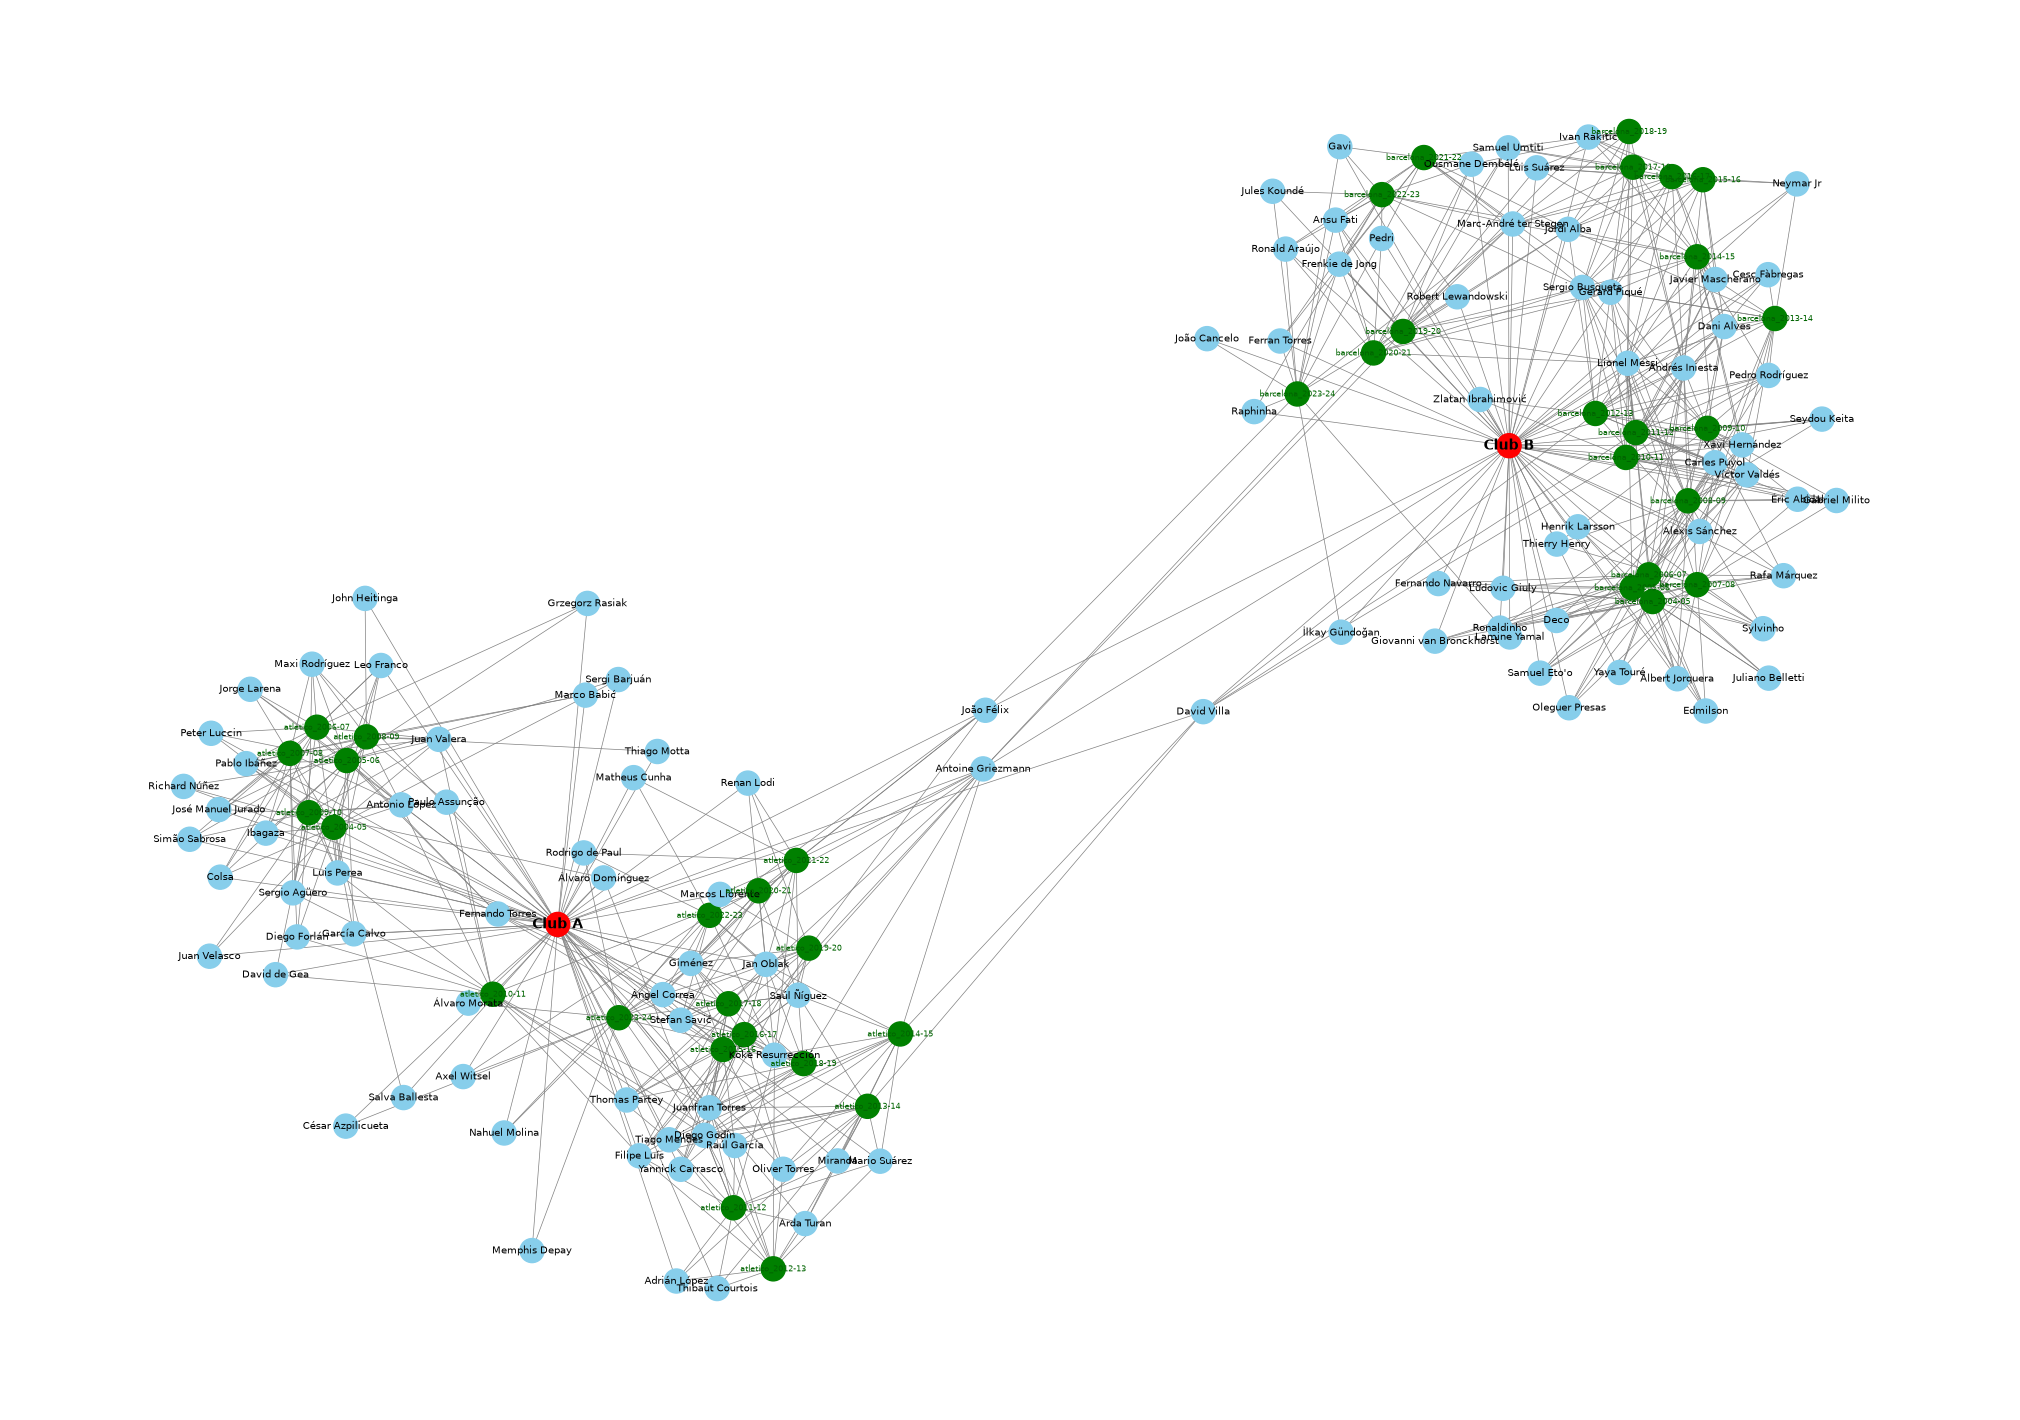

In [3]:
import os
import pandas as pd
from collections import defaultdict
import networkx as nx
import matplotlib.pyplot as plt

# relación: jugador -> lista de (club, temporada)
relacion = defaultdict(list)

def cargar_relacion(ruta, club):

    for archivo in os.listdir(ruta):
        if archivo.endswith(".csv"):

            # Extraemos temporada del nombre del fichero
            temporada = archivo.replace(".csv", "")

            df = pd.read_csv(os.path.join(ruta, archivo))

            for jugador in df["jugador"].dropna():
                relacion[jugador].append((club, temporada))

    print(dict(relacion))

relacion = defaultdict(list)

cargar_relacion("../../datasets/atletico", "Club A")
cargar_relacion("../../datasets/barcelona", "Club B")

tabla = []

for jugador, valores in relacion.items():
    for club, temporada in valores:
        tabla.append([jugador, club, temporada])

df_relacion = pd.DataFrame(tabla, columns=["Jugador", "Club", "Temporada"])

display(df_relacion)

print(dict(relacion))

G = nx.Graph()

for jugador, valores in relacion.items():
    for club, temporada in valores:
        G.add_node(jugador, type="jugador")
        G.add_node(club, type="club")
        G.add_node(temporada, type="temporada")

        G.add_edge(jugador, club)
        G.add_edge(jugador, temporada)

plt.figure(figsize=(20, 14))

pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)

# Colorea los nodos según su tipo (jugador, club, temporada)
colores = []
for nodo in G.nodes():
    tipo = G.nodes[nodo].get("type")
    if tipo == "club":
        colores.append("red")
    elif tipo == "temporada":
        colores.append("green")
    else:
        colores.append("skyblue")

# Dibuja los nodos y las aristas sin etiquetas
nx.draw(
    G, pos,
    with_labels=False,
    node_size=300,
    node_color=colores,
    edge_color="gray",
    width=0.5
)

# Etiquetas separadas por tipo de nodo, con distinto tamaño/color para diferenciarlas
labels_jugadores = {n: n for n in G.nodes() if G.nodes[n].get("type") == "jugador"}
labels_clubs = {n: n for n in G.nodes() if G.nodes[n].get("type") == "club"}
labels_temporadas = {n: n for n in G.nodes() if G.nodes[n].get("type") == "temporada"}

nx.draw_networkx_labels(G, pos, labels=labels_jugadores, font_size=7)
nx.draw_networkx_labels(G, pos, labels=labels_clubs, font_size=10, font_weight="bold")
nx.draw_networkx_labels(G, pos, labels=labels_temporadas, font_size=6, font_color="darkgreen")

plt.show()

In [4]:
from collections import Counter

contador_temporadas = Counter()

for jugador, valores in relacion.items():
    temporadas = set([v[1] for v in valores])
    contador_temporadas[jugador] = len(temporadas)

# máximo
max_temporadas = max(contador_temporadas.values())

jugadores_top = [j for j, v in contador_temporadas.items() if v == max_temporadas]

print("Jugadores con más temporadas:", jugadores_top)
print("Número de temporadas:", max_temporadas)

club_a_rel = 0
club_b_rel = 0

for jugador, valores in relacion.items():
    for club, temporada in valores:
        if club == "Club A":
            club_a_rel += 1
        elif club == "Club B":
            club_b_rel += 1

print("Relaciones Club A:", club_a_rel)
print("Relaciones Club B:", club_b_rel)

if club_a_rel > club_b_rel:
    print("Club A es más denso")
elif club_b_rel > club_a_rel:
    print("Club B es más denso")
else:
    print("Ambos tienen la misma densidad")

Jugadores con más temporadas: ['Lionel Messi']
Número de temporadas: 17
Relaciones Club A: 264
Relaciones Club B: 287
Club B es más denso
